In [1]:
import os
import re
import numpy as np
import pandas as pd
import geopandas as gpd
from matplotlib import pyplot as plt
from rapidfuzz import fuzz
from itertools import combinations
from shapely.geometry import MultiPoint
from geopy import distance
from shapely import Point

from rapidfuzz import fuzz
from itertools import combinations
from shapely.geometry import multipoint

# NWT Databases

## OROGO

In [2]:
# OROGO database
OROGO = pd.read_csv('source_data/wells/NWT/orogo-well-status-updated-2026-04-10.csv').drop(columns=['NAD 27 Lat','NAD 27 Long','Unnamed: 16','Unnamed: 17']).dropna(how='all')
OROGO = gpd.GeoDataFrame(data=OROGO,geometry=gpd.points_from_xy(x=OROGO['NAD_83_LongDD'],y=OROGO['NAD_83_LatDD']),crs='NAD1983')
OROGO['Name'] = OROGO['Well Name'].str.upper()
OROGO = OROGO.set_index('Name',drop=False)
OROGO = OROGO.drop(columns='geometry')
OROGO[['y','x']] = OROGO[['NAD_83_LatDD', 'NAD_83_LongDD']]
OROGO['DS_UID'] = [f'OROGO-{i}' for i in range(0,len(OROGO))]
OROGO['First SPUD year'] = pd.to_datetime(OROGO['First SPUD year'],format='%Y')
print(len(OROGO))
print(OROGO.columns)

685
Index(['Well ID', 'Well Name', 'Last Operator', 'Current or Last Owner',
       'Well Status', 'Classification', 'First SPUD year',
       'Latest SPUD or Start Date', 'Latest Rig Release or End Date',
       'Land Title', 'Region', 'NAD_83_LatDD', 'NAD_83_LongDD', 'UWI', 'Name',
       'y', 'x', 'DS_UID'],
      dtype='str')


## NTGS Open Report 2009-03

In [3]:
NTGS_2009_03 = [r'source_data\wells\NWT\2009-03_Well_Sites\Well_Sites.shp',r'source_data\wells\NWT\2009-03_Well_Sites\Well_Sites_Peripheral.shp']
NTGS_2009_03 = pd.concat([gpd.read_file(fn).set_index('UWI') for fn in NTGS_2009_03]).to_crs('NAD1983')
# Fix a typo
NTGS_2009_03['WELL_NAME']=NTGS_2009_03['WELL_NAME'].str.replace('S. Tuttle YT -05','S. Tuttle YT N-05')
NTGS_2009_03['WELL_NAME']=NTGS_2009_03['WELL_NAME'].str.replace('Peel R ','Peel River ').str.replace('Peel R. ','Peel River ')
NTGS_2009_03['WELL_NAME']=NTGS_2009_03['WELL_NAME'].str.replace('Crown Bell River "YT-A" No.1 (N-50)','Crown Bell River "YT-A" No.1 N-50')
NTGS_2009_03['Name'] = NTGS_2009_03['WELL_NAME'].str.upper()
NTGS_2009_03['NAD_83_LatDD'] = NTGS_2009_03.geometry.y
NTGS_2009_03['NAD_83_LongDD'] = NTGS_2009_03.geometry.x
NTGS_2009_03 = NTGS_2009_03.reset_index().set_index('Name',drop=False)
NTGS_2009_03 = NTGS_2009_03.drop(columns='geometry')
NTGS_2009_03[['y','x']] = NTGS_2009_03[['NAD_83_LatDD', 'NAD_83_LongDD']]
NTGS_2009_03['DS_UID'] = [f'NTGS_2009_03-{i}' for i in range(0,len(NTGS_2009_03))]
NTGS_2009_03['SPUD_DATE'] = pd.to_datetime(NTGS_2009_03['SPUD_DATE'])
print(len(NTGS_2009_03))
print(NTGS_2009_03.columns)

549
Index(['UWI', 'WID', 'WELL_NAME', 'OPERATOR', 'STATUS', 'CLASSIFICA',
       'SPUD_DATE', 'RIG_RELEAS', 'LAT', 'LONG', 'DATUM', 'NORTHING',
       'EASTING', 'ZONE', 'SOURCE', 'REFERENCE', 'Name', 'NAD_83_LatDD',
       'NAD_83_LongDD', 'y', 'x', 'DS_UID'],
      dtype='str')


## NTGS Open Report 2019-015

In [4]:
# Report 2019-015
NTGS_2019_015_g = gpd.read_file(r'source_data\wells\NWT\2019-015_Shapefiles\Gas_Resource.shp').set_index('Well_Names',drop=False).rename(columns={'Recoverabl':'Recoverabl_gas'})
NTGS_2019_015_o = gpd.read_file(r'source_data\wells\NWT\2019-015_Shapefiles\Oil_Resource.shp').set_index('Well_Names',drop=False).rename(columns={'Recoverabl':'Recoverabl_oil'})

NTGS_2019_015 = pd.concat([
    NTGS_2019_015_g,
    NTGS_2019_015_o.loc[~NTGS_2019_015_o.index.isin(NTGS_2019_015_g.index),NTGS_2019_015_o.columns[NTGS_2019_015_o.columns!='Recoverabl_oil']]
]).to_crs('NAD1983')
NTGS_2019_015 = NTGS_2019_015.join(NTGS_2019_015_o[['Recoverabl_oil']],how='left')
NTGS_2019_015['NAD_83_LatDD'] = NTGS_2019_015.geometry.y
NTGS_2019_015['NAD_83_LongDD'] = NTGS_2019_015.geometry.x
NTGS_2019_015 = NTGS_2019_015.drop(columns='geometry')
NTGS_2019_015[['y','x']] = NTGS_2019_015[['NAD_83_LatDD', 'NAD_83_LongDD']]
# Fix a typos
NTGS_2019_015['Well_Names']=NTGS_2019_015['Well_Names'].str.replace('Ya Ya','YaYa')
NTGS_2019_015['Well_Names']=NTGS_2019_015['Well_Names'].str.replace('Tarsuit','Tarsiut')
NTGS_2019_015['Well_Names']=NTGS_2019_015['Well_Names'].str.replace('Koakaok','Koakoak')

NTGS_2019_015['Name'] = NTGS_2019_015['Well_Names'].str.upper()
NTGS_2019_015 = NTGS_2019_015.set_index('Name',drop=False)

NTGS_2019_015 = NTGS_2019_015.sort_index()
NTGS_2019_015 = NTGS_2019_015.loc[~NTGS_2019_015[['UWI']].duplicated(keep='first')]
NTGS_2019_015['DS_UID'] = [f'NTGS_2019_015-{i}' for i in range(0,len(NTGS_2019_015))]
NTGS_2019_015['Discovery'] = pd.to_datetime(NTGS_2019_015['Discovery'],format='%Y')

NTGS_2019_015

print(len(NTGS_2019_015))
# print(NTGS_2019_015.columns)

167


# Yukon Data

In [5]:
GeoYukon = gpd.read_file(r'source_data\wells\yukon\Oil_and_Gas_Wells_50k.shp').to_crs('NAD1983').rename(columns={'WELL_UWI':'UWI'})
GeoYukon['DATE'] = GeoYukon['DATE'].replace('0000/00/00',pd.NaT)
GeoYukon['DATE'] = pd.to_datetime(GeoYukon['DATE'])
# Fix a typo
GeoYukon['WELL_NAME'] = GeoYukon['WELL_NAME'].str.replace('Peel R ','Peel River ').str.replace('Peel R. ','Peel River ')
GeoYukon['WELL_NAME'] = GeoYukon['WELL_NAME'].str.replace('Shell ','')
GeoYukon['WELL_NAME'] = GeoYukon['WELL_NAME'].str.replace('Amerada et al Crown','Crown Bell River')
GeoYukon['WELL_NAME'] = GeoYukon['WELL_NAME'].str.replace('Amoco PCP B-1 Cranswick YT A-42','Cranswick YT A-42')

GeoYukon['Name'] = GeoYukon['WELL_NAME'].str.upper()
GeoYukon = GeoYukon.set_index('Name',drop=False)
GeoYukon['NAD_83_LatDD'] = GeoYukon.geometry.y
GeoYukon['NAD_83_LongDD'] = GeoYukon.geometry.x
GeoYukon = GeoYukon.drop(columns='geometry')
GeoYukon[['y','x']] = GeoYukon[['NAD_83_LatDD', 'NAD_83_LongDD']]
GeoYukon['DS_UID'] = [f'GeoYukon-{i}' for i in range(0,len(GeoYukon))]
print(len(GeoYukon))

76


# Federal Data

## Basin

In [6]:
Basin = pd.read_csv('source_data/wells/Basin/BASIN_well_coords.txt',delimiter='\t',skiprows=3).drop(columns=['Latitude (NAD27)','Longitude (NAD27)','Northing (NAD27)','Easting (NAD27)'])
Basin2 = pd.read_csv('source_data/wells/Basin/q1787332704.txt',delimiter='\t',skiprows=3).rename(columns={'Unique Well Identifier':'UWI'})
Basin2['UWI'] = Basin2['UWI'].str.replace(' ','')
Basin = pd.merge(Basin,Basin2[['Well Name','GSC #','Original Spud Year','Operator','Status','UWI']],on='Well Name',how='left')#.set_index('UWI')
Basin['Name'] = Basin['Well Name'].str.upper()
Basin = Basin.set_index('Name',drop=False)
Basin = Basin.sort_values(by='Original Spud Year')
Basin = Basin.loc[~Basin[['Name','UWI']].duplicated(keep='first')].copy()
Basin = Basin.loc[Basin['Latitude (NAD83)']>60]
Basin[['y','x']] = Basin[['Latitude (NAD83)', 'Longitude (NAD83)']]
Basin['DS_UID'] = [f'Basin-{i}' for i in range(0,len(Basin))]
Basin['Original Spud Year'] = pd.to_datetime(Basin['Original Spud Year'],format='%Y')
print(len(Basin))
print(Basin.columns)

179
Index(['Well Name', 'Basin', 'Subbasin', 'Latitude (NAD83)',
       'Longitude (NAD83)', 'Northing (NAD83)', 'Easting (NAD83)',
       'Zone (UTM)', 'GSC #', 'Original Spud Year', 'Operator', 'Status',
       'UWI', 'Name', 'y', 'x', 'DS_UID'],
      dtype='str')


## CER

* Missing UWI

In [7]:
CER = pd.read_csv(r'source_data\wells\CER\Frontier_Wells_Inuvik_Region.csv')
#Fix Typo
CER['WELL_NAME']=CER['WELL_NAME'].str.replace('AMAULIGAK CH NO.1','AMAULIGAK COREHOLE NO.1')
CER['Name'] = CER['WELL_NAME'].str.upper()
CER['UWI'] = None
CER = CER.set_index('Name',drop=False)
CER[['y','x']] = CER[['NAD_83_LAT', 'NAD_83_LON']]
CER['DS_UID'] = [f'CER-{i}' for i in range(0,len(CER))]
print(len(CER))
print(CER.columns)

367
Index(['WELL_ID', 'WELL_NAME', 'OPERATOR', 'STATUS', 'LAND_TITLE', 'REGION',
       'NAD_83_LAT', 'NAD_83_LON', 'Name', 'UWI', 'y', 'x', 'DS_UID'],
      dtype='str')


## GSC Open Files 

* some missing key identifiers, so pre-synthesis needed for better record matching

## GSC Open File 6959

In [8]:
GSC_6959 = pd.read_csv(r'source_data\wells\GSC\GSC_OF_6959.csv')#@.set_index('UWI')
GSC_6959['Name'] = GSC_6959['Well Short Name'].str.upper()
GSC_6959=GSC_6959.set_index('Name',drop=False)
GSC_6959[['y','x']] = GSC_6959[['SURF_LAT', 'SURF_LONG']]
GSC_6959['DS_UID'] = [f'GSC_6959-{i}' for i in range(0,len(GSC_6959))]
print(len(GSC_6959))
print(GSC_6959.columns)

265
Index(['UWI', 'Well Short Name', 'EASTING', 'NORTHING', 'MAP_DATUM',
       'SURF_LAT', 'SURF_LONG', 'UTMZONE', 'Well Status', 'KB (m)', 'GL (m)',
       'Final Interpretation, Ice-bearing permafrost base, Base of fully frozen (mKB)',
       'Final Interpretation Ice-bearing permafrost base Base of fully frozen (mGL/SF)',
       'Final Interpretation Ice-bearing permafrost base Quality', 'Formation',
       'Final Interpretation Ice-bearing permafrost base Base of partially frozen (mKB)',
       'Final Interpretation Ice-bearing permafrost base Base of partially frozen (mGL/SF)',
       'Final Interpretation Ice-bearing permafrost base Quality.1',
       'Final Interpretation Ice-bearing permafrost base Transition zone thickness (m)',
       'Final Interpretation Ice-bearing permafrost base Formation/ Sequence ',
       'Final Interpretation Ice-bearing permafrost base PF present',
       'Final Interpretation Ice-bearing permafrost base Data used for final pick*',
       'Base of 

## GSC Open File 4828 & 327948

In [9]:
# Missing UWI
GSC_4828 = pd.read_csv(r'source_data\wells\GSC\GSC_OF_4828.csv')
for c in ['Latitude', 'Longitude']:
    DMS = pd.DataFrame(GSC_4828[c].replace(r'[^0-9.]',' ',regex=True).str.split().to_list(),columns=['D','M','S'],index=GSC_4828['Well Name'])
    GSC_4828[c] = (DMS['D'].astype('float')+DMS['M'].astype('float')/60+DMS['S'].astype('float')/3600).values
GSC_4828['Longitude'] *= -1
GSC_4828['Name'] = GSC_4828['Well Name'].str.upper()
GSC_4828 = GSC_4828.set_index('Name',drop=False)
GSC_4828[['y','x']] = GSC_4828[['Latitude', 'Longitude']]

# # Missing coordinates but contains UWI
GSC_327948 = pd.read_csv(r'source_data\wells\GSC\GSC_OF_327948.csv')
GSC_327948['Name'] = GSC_327948['Well name'].str.upper()
GSC_327948 = GSC_327948.set_index('Name',drop=False)
GSC_327948 = GSC_327948.loc[GSC_327948['UWI'].duplicated(keep='first')].copy()
GSC_327948[['x','y']] = None,None
# Get from GSC_6959 & 327948
GSC_4828=GSC_4828.join(GSC_6959[['UWI']],how='left')
for k,v in GSC_4828.loc[GSC_4828['UWI'].isna(),'Name'].isin(GSC_327948['Name']).items():
    if v:
        GSC_4828.loc[GSC_4828.index==k,'UWI'] = GSC_327948.loc[GSC_327948.index==k,'UWI']
GSC_4828['DS_UID'] = [f'GSC_4828-{i}' for i in range(0,len(GSC_4828))]
GSC_327948['DS_UID'] = [f'GSC_327948-{i}' for i in range(0,len(GSC_327948))]
print(len(GSC_4828))
print(GSC_4828.columns)

print(len(GSC_327948))
print(GSC_327948.columns)


263
Index(['Well No.', 'Company', 'Well Name', 'Latitude', 'Longitude', 'KBm',
       'GLm', 'TD(ft)', 'TD(m)', 'TVD', 'Name', 'y', 'x', 'UWI', 'DS_UID'],
      dtype='str')
40
Index(['UWI', 'Well name', 'Top of overpressure zone mSl',
       'Top of overpressure zone mGl', 'Top of overpressure zone quality',
       'Sequence', 'Comments', 'Name', 'x', 'y', 'DS_UID'],
      dtype='str')


# Consultant Reports

## Arktis report for ILA

In [10]:
ILA = pd.read_csv(r'source_data\wells\ISR\ISR_well_report_B1.csv')
ILA = ILA.loc[~ILA['Latitude (NAD83) -Well Post'].isna()].copy()
for c in ['Latitude (NAD83) -Well Post','Longitude (NAD83) -Well Post']:
    DMS = pd.DataFrame(ILA[c].replace(r'[^0-9.]',' ',regex=True).str.split().to_list(),columns=['D','M','S'],index=ILA['Well Name'])
    ILA[c] = (DMS['D'].astype('float')+DMS['M'].astype('float')/60+DMS['S'].astype('float')/3600).values
ILA['Longitude (NAD83) -Well Post'] *= -1

#Fix typo
ILA['Well Name'] = ILA['Well Name'].str.replace('CROSSLEY LK','CROSSLEY LAKE')
ILA['Well Name'] = ILA['Well Name'].str.replace('ATERTAK K-31','ATERTAK L-31')


ILA['Name'] = ILA['Well Name'].str.upper()
ILA = ILA.set_index('Name',drop=False)
ILA[['y','x']] = ILA[['Latitude (NAD83) -Well Post','Longitude (NAD83) -Well Post']]

ILA['Original Spud Date'] = pd.to_datetime(ILA['Original Spud Date'],format="%d-%b-%y",errors='coerce').map(lambda x: x.replace(year=x.year - 100) if x.year >= 2040 else x)
ILA['DS_UID'] = [f'ILA-{i}' for i in range(0,len(ILA))]
print(len(ILA))
print(ILA.columns)

227
Index(['WID', 'Consortium', 'Current Owner', 'Land Owner', 'Well Name', 'UWI',
       'Class', 'Status', 'Latitude (NAD83) -Well Post',
       'Longitude (NAD83) -Well Post', 'Region', 'Original Spud Date',
       'Original Rig Release Date', 'Depth (m)', 'Notes', 'Name', 'y', 'x',
       'DS_UID'],
      dtype='str')


## LTLC Report

In [11]:
LTLC = pd.read_csv('source_data/wells/misc/LTLC_report.csv')
LTLC = LTLC.set_index('Name',drop=False)
LTLC['UWI'] = None
LTLC[['x','y']] = None,None


LTLC['Spud_Date'] = pd.to_datetime(LTLC['Spud_Date'])
LTLC['DS_UID'] = [f'LTLC-{i}' for i in range(0,len(LTLC))]
print(len(LTLC))
print(LTLC.columns)

92
Index(['Name', 'Operator', 'Spud_Date', 'RIG RELEASE', 'DRILLING PLATFORM',
       'WATER DEPTH (M)', 'UWI', 'x', 'y', 'DS_UID'],
      dtype='str')


# Aggregating

In [19]:

def dfilter(X,mask):
	out = {key:value for key,value in X.items() if key not in mask and value not in mask}
	if len(out) == 1:
		out = list(out.values())[0]
	return(out)	

def filter(X,mask=['None','NONE',None,np.nan],fuzzmask=None):
    if type(X) is dict:
        return(dfilter(X,mask))
    elif type(X) is list:
        out = [x for x in X if x not in mask]
        if len(out) == 0:
            return (None)
        elif len(out)==1:
            return(out[0])
        elif fuzzmask is None:
            return(out)
        else:
            fuzzyMin = min([fuzz.partial_ratio(c[0],c[1]) for c in combinations(out,2)])
            if fuzzyMin>=fuzzmask:
                out.sort()
                out = out[0]
            return(out)
    else:
        return(X)

def listCheck(X,contains=None):
	if contains is None:
		return(type(X) is list)
	else:
		if type(X) is list:
			any([x in contains for x in X])
		else:
			return(False)


def distance_check(xy_in,thresh=250):
	if len(xy_in)==1:
		return(list(xy_in.values())[0])
	else:
		xy_clean = [v for v in xy_in.values() if not np.isnan(v.x)]
		if len(xy_clean)<2:
			return xy_clean[0]
		d = [distance.distance((v1.y,v1.x),(v2.y,v2.x),ellipsoid='WGS-84').meters for v1,v2 in list(combinations(xy_clean,r=2))]
		d.sort()
		if max(d) > thresh:
			x = sum([x.x for x in xy_clean])/len(xy_clean)
			y = sum([y.y for y in xy_clean])/len(xy_clean)
			print(len(d)/2)
			return([xy_clean,max(d)])
		else:
			x = sum([x.x for x in xy_clean])/len(xy_clean)
			y = sum([y.y for y in xy_clean])/len(xy_clean)
			return(Point(x,y))


def companies(company,rep=None):
    if rep is None:
        rep = {
            'MARATHON':['CANADIAN FOREST'],
            'Dome':['DOME',"HUDSON'S BAY OIL",'HOME OIL'],
            'DEMINEX':['DEMINEX'],
            'MOBIL':['MOBIL','STANDARD','CANADIAN SUPERIOR'],
            'GSC':['JAPEX','AURORA COLLEGE'],
            'TRILLIUM':['TRILLIUM'],
            'INTER-CITY':['INTER-','WESTERN HOMESTEAD','CANADIAN HOMESTEAD'],
            'HUNT':['HUNT'],
            'ANDERSON':['ANDERSON','PC ANDERSON','COLUMBIA GAS'],
            'IMPERIAL OIL':['IMP','ESSO','NORTHWEST OILS','UNITED CANSO ','DOM.EXPLORERS-CANSO','I.O.E.'],
            'SHELL':['SHELL'],
            'CHEVRON':['CHEVRON','TEXACO','TEXCAN','HORN RIVER CCS GETTY','THE CALIFORNIA STANDARD','UNOCAL','CANADIAN RESERVE OIL AND GAS LTD'],
            'BP':['AMOCO','ATLANTIC RICHFIELD','BP','RICHFIELD OIL CORPORATION','ARCO','PAN AMERICAN','COLUMBIA ET AL AMOCO','B P O G'],
            'PARAMOUNT RESOURCES':['PARAMOUNT','MGM','APACHE '],
            'CENOVUS':['CENOVUS','HUSKY'],
            'CANADIAN NATURAL RESOURCES':['CANADIAN NATURAL RESOURCES','RANGER','DEVON','PC DEVON'],
            'ENCANA':['ENCANA','CANADIAN PACIFIC OIL & GAS','C.P.O.G.'],
            'TOTAL':['ELF','AQUITAINE','ELFEX','FRENCH PETROLEUM','TOTAL '],
            'CONOCOPHILLIPS':['CONOCO','GULF','PHILLIPS ','INEXCO OIL CO. AND HUSKY'],
            'SUNCOR ENERGY':['SUNCOR','PANARCTIC','B.A.','BRITISH AMERICAN','AMERADA','PETRO-CANADA ','PETROFINA ','HORN RIVER PANARCTIC','SUN','PC ','PACIFIC PETROLEUMS','PACIFIC ET AL.'],
            'OCCIDENTAL':['GREAT PLAINS','NORCERN','KERR '],
            'CANADIAN OIL SANDS':['CANADA SOUTHERN PETROLEUM LTD'],
            'INUVIALUIT PETROLEUM CORPORATION':['IPC','INUVIALUIT'],
            None:['NAN']
            }
    company = str(company).upper()
    for key,val in rep.items():
        if any([company.startswith(v) for v in val]):
            company = key
            break
    if company == '' or company == 'UNCERTAIN' or company is None:
        company = 'UNCERTAIN'
    return(company)
def status(stat):
    rep = {'P&A':'Plugged','PLUG':'Plugged','OTHER':'Abandoned','ABANDONED':'Abandoned','SUSP':'Suspended','OIL':None,'GAS':None,'INJECTOR':None}
    if not type(stat) is str:
        return(None)
    for key,value in rep.items():
        if key in stat.upper():
            stat = value
            break
    return(stat)

# Combine records

First step is to fill missing UWI values

In [ ]:
dataSet = {
'OROGO':OROGO,
'NTGS_2009_03':NTGS_2009_03,
'NTGS_2019_015':NTGS_2019_015,
'GeoYukon':GeoYukon,
'Basin':Basin,
'CER':CER,
'GSC_327948':GSC_327948,
'GSC_4828':GSC_4828,
'GSC_6959':GSC_6959,
'ILA':ILA,
'LTLC':LTLC
}

columns_by_source = {
	'Company':{
		'OROGO':'Current or Last Owner',
		'NTGS_2009_03':'OPERATOR',
		'NTGS_2019_015':None,
		'GeoYukon':'LICENSEE',
		'Basin':'Operator',
		'CER':'OPERATOR',
		'GSC_327948':None,
		'GSC_4828':'Company',
		'GSC_6959':None,
		'ILA':'Current Owner',
		'LTLC':'Operator'
			},
	'Spud_Year':{
		'OROGO':'First SPUD year',
		'NTGS_2009_03':'SPUD_DATE',
		'NTGS_2019_015':'Discovery',
		'GeoYukon':'DATE',
		'Basin':'Original Spud Year',
		'CER':None,
		'GSC_327948':None,
		'GSC_4828':None,
		'GSC_6959':None,
		'ILA':'Original Spud Date',
		'LTLC':'Spud_Date'
	},
	'Status':{
		'OROGO':'Well Status',
		'NTGS_2009_03':'STATUS',
		'NTGS_2019_015':None,
		'GeoYukon':'STATUS',
		'Basin':'Status',
		'CER':'STATUS',
		'GSC_327948':None,
		'GSC_4828':None,
		'GSC_6959':'Well Status',
		'ILA':'Status',
		'LTLC':None
	}
}

# Corrections
for key,value in dataSet.items():
    df = dataSet[key]
    # A UID for backtracking all records
    df['Data_Source'] = key
    df['UWI'] = df['UWI'].fillna('None').astype('str').str.lstrip()
    # Removed secondary codes
    df['Name'] = df['Name'].str.split(r'(').str[0]
    df['Code'] = df['Name'].str.extract(r".*(\d[a-zA-Z]-\d+[a-zA-Z]{,})").fillna(df['Name'].str.extract(r".*([a-zA-Z]-\d+[a-zA-Z]{,})")).fillna('~')
    df['Short_Name'] = [t.split(n)[0] if t.split(n)[0] != '' else t.split(n)[-1] for t,n in zip(df['Name'],df['Code'])]
    df['Short_Name'] = df['Short_Name'].str.replace(r'[^a-zA-Z0-9\s]', '', regex=True).str.rstrip()
    df.loc[df['Short_Name']=='',['Name','Code']]
    for k,v in columns_by_source.items():
        if v[key] is None:
            df[k] = None
        else:
            df[k] = df[v[key]]
            if k == 'Company':
                # Update and standardize names
                df[k] = df[k].apply(companies)
            if k == 'Status':
                # Update and standardize names
                df[k] = df[k].apply(status)
# First pass merge
AllData = pd.concat([d[['Name','Short_Name','Code','UWI','Data_Source','DS_UID','x','y']+list(columns_by_source.keys())] for d in dataSet.values()])
AllPoints = gpd.GeoDataFrame(data=AllData,geometry=gpd.points_from_xy(x=AllData['x'],y=AllData['y']),crs='NAD1983').to_crs('WGS1984')
AllPoints['OID'] = [i for i in range(0,len(AllPoints))]
AllPoints = AllPoints.set_index('DS_UID')

# Sync names for those with UIW
UWI = AllPoints.loc[AllPoints['UWI']!='None'].groupby('UWI').agg(set)[['Short_Name','Code']]

UWI['Short_Name']=UWI['Short_Name'].apply(list).apply(lambda x: filter(x,fuzzmask=90))
UWI['Code']=UWI['Code'].apply(list).apply(filter)

# Find records without UWI and attempt match
noUWI = AllPoints.loc[AllPoints['UWI']=='None'].groupby(['Short_Name','Code','DS_UID']).agg(list)[['UWI']]
noUWI['UWI'] = noUWI['UWI'].apply(filter)
noUWI = noUWI.reset_index()


for key,source in noUWI.iterrows():
    uwi = UWI.loc[((UWI['Short_Name']==source['Short_Name'])&(UWI['Code']==source['Code']))].sort_values(by='UWI')
    if len(uwi)==1:
        noUWI.loc[key,'UWI'] = uwi.index[0]
        AllPoints.loc[AllPoints.index==source['DS_UID'],'UWI'] = uwi.index[0]
    elif len(uwi) > 1:
         # If multiples, just take "first" UWI
        noUWI.loc[key,'UWI'] = uwi.index[0]
        AllPoints.loc[AllPoints.index==source['DS_UID'],'UWI'] = uwi.index[0]

noMatch = noUWI[noUWI['UWI'].isna()].groupby(['Short_Name','Code']).agg(list)
noMatch['UWI'] = [f"UWI_missing_{i}" for i in range(0,len(noMatch))]
for i,row in noMatch.iterrows():
    for uid in row['DS_UID']:
        AllPoints.loc[AllPoints.index==uid,'UWI'] = row['UWI']

# Verify every record now has UWI
AllPoints.loc[AllPoints['UWI'].isna()]

AllPoints[AllPoints['Company'].isna()]



,Name,Short_Name,Code,UWI,Data_Source,x,y,Company,Spud_Year,Status,geometry,OID
DS_UID,,,,,,,,,,,,
NTGS_2019_015-0,ADGO F-28,ADGO,F-28,300F286930135450,NTGS_2019_015,-135.857231,69.45475,None,1974-01-01 00:00:00,None,POINT (-135.85723 69.45475),1234
NTGS_2019_015-1,ADGO G-24,ADGO,G-24,300G246930135450,NTGS_2019_015,-135.844264,69.408928,None,1986-01-01 00:00:00,None,POINT (-135.84426 69.40893),1235
NTGS_2019_015-2,ADGO H-29,ADGO,H-29,300H296930135450,NTGS_2019_015,-135.840452,69.472321,None,1985-01-01 00:00:00,None,POINT (-135.84045 69.47232),1236
NTGS_2019_015-3,ADGO J-27; ADGO J-27,ADGO,J-27,300J276930135450,NTGS_2019_015,-135.846569,69.44229,None,1979-01-01 00:00:00,None,POINT (-135.84657 69.44229),1237
NTGS_2019_015-4,ADGO P-25; ADGO P-25,ADGO,P-25,300P256930135450,NTGS_2019_015,-135.844675,69.417739,None,1975-01-01 00:00:00,None,POINT (-135.84468 69.41774),1238
...,...,...,...,...,...,...,...,...,...,...,...,...
GSC_6959-260,WOLVERINE H-34,WOLVERINE,H-34,300H346830130300,GSC_6959,-130.6358,68.388646,None,None,Abandoned,POINT (-130.6358 68.38865),2586
GSC_6959-261,YAYA A-28,YAYA,A-28,300A286920134300,GSC_6959,-134.593608,69.286333,None,None,NaN,POINT (-134.59361 69.28633),2587
GSC_6959-262,YAYA I-17,YAYA,I-17,300I176920134300,GSC_6959,-134.549721,69.276335,None,None,Abandoned,POINT (-134.54972 69.27634),2588


regroup by UWI

In [ ]:
def cleanPoints(geom):
    geom = [g for g in geom if not g.is_empty and g is not None and not (np.isinf(g.x) or np.isinf(g.y) or np.isnan(g.x) or np.isinf(g.y))]
    return(geom)
def dispersion(geom):
    geom = cleanPoints(geom)
    if len(geom)>1:
        yx = list(combinations(geom,r=2))
        d = np.array([distance.distance(p1.coords[0][::-1],p2.coords[0][::-1],ellipsoid='WGS-84').meters for p1,p2 in yx])
        return(sum(d)/len(d))
    elif len(geom) == 1:
        return(0)
    else:
        return(np.nan)
    
def centroid(geom):
    geom = cleanPoints(geom)
    if len(geom)>1:
        geom = Point(np.array([g.coords[0] for g in geom]).mean(axis=0))
        return(geom)
    else:
        geom = geom[0]
    return(geom)

UTM = {
    7:-141,8:-135,9:-129,10:-123,11:-117,12:-111,13:-105,14:-99,15:-93,16:-87,17:-81,18:-75,19:-69,20:-63,21:-57
    }

AllPoints['Zone'] = np.nan
# AllPoints['Meridian'] = AllPoints['x'].astype('float')
AllPoints['Centroid'] = None
groups = AllPoints[['UWI','x']].groupby('UWI').mean()['x']
for zone,meridian in UTM.items():
    ix = groups[(groups-meridian).abs()<3].index
    px = AllPoints.loc[AllPoints['UWI'].isin(ix)].to_crs(f'NAD83(CSRS) / UTM zone {zone}N').groupby('UWI').agg(list).geometry
    pts = px.apply(centroid)
    pts = gpd.GeoSeries(pts,crs=f'NAD83(CSRS) / UTM zone {zone}N').to_crs('WGS1984')
    for ix,pt in pts.items():
        AllPoints.loc[AllPoints['UWI']==ix,'Centroid'] = pt
geom = AllPoints.groupby('UWI').first()['Centroid']

names = AllPoints.groupby('UWI').agg(set)[['Data_Source','Short_Name','Code','Company','Spud_Year','Status']]
CentrePoints = AllPoints.drop(columns=['geometry','Centroid','Zone','Name']).groupby('UWI').agg(list)
CentrePoints['replicates'] = AllPoints.groupby('UWI').count()['Name']
CentrePoints[['Data_Source','Short_Name','Code','Company','Spud_Year','Status']] = names
for c in ['OID','Spud_Year','Status','Data_Source','Company']:
    CentrePoints[c] = CentrePoints[c].apply(list).apply(filter)
for c in ['Short_Name','Code']:
    # Aggregate similar names with matching uwi (already done earlier, but must reapply for spatial grouping)
    CentrePoints[c] = CentrePoints[c].apply(list).apply(filter).apply(lambda x: filter(x,fuzzmask=90))
for c in ['Data_Source','Company']:
    CentrePoints.loc[CentrePoints[c].apply(listCheck),c] = CentrePoints.loc[CentrePoints[c].apply(listCheck),c].apply(';'.join)
CentrePoints['Name'] = CentrePoints['Short_Name']+' '+CentrePoints['Code']
def dispersion(xy):
    cx = list(combinations([(x,y) for x,y in zip (xy['x'],xy['y'])],r=2))
    if not len(cx):
        return(0)
    else:
        d = np.array([distance.distance(p1[::-1],p2[::-1],ellipsoid='WGS-84').meters for p1,p2 in cx])
        return(d.std())
CentrePoints['Multi_Point_Distance_std'] = CentrePoints[['x','y']].T.apply(dispersion)
# Format string representation for x/y coordinates (for when multipoint dispersion is high) to help with finding well sites
CentrePoints[['x','y']] = AllPoints[['x','y','UWI']].groupby('UWI').agg(dict)
def fmt(xy):
    f = []
    for key,x in xy['x'].items():
        y = xy['y'][key]
        f.append(f"{key}({x},{y})")
    return('; '.join(f))
CentrePoints['Source_Coordinates']=CentrePoints[['x','y']].T.apply(fmt)
CentrePoints = gpd.GeoDataFrame(data=CentrePoints.drop(columns=['x','y']),geometry=geom,crs='WGS1984')

In [31]:
CA_boundary = gpd.read_file('source_data/boundary/provinces.shp')

CentrePoints['Territory'] = 'Off-Shore'
CentrePoints = CentrePoints.to_crs(CA_boundary.crs)
for pruid in ['60','61','62']:
    CentrePoints.loc[CentrePoints.within(CA_boundary.loc[CA_boundary['PRUID']==pruid].geometry.values[0]),'Territory'] = CA_boundary.loc[CA_boundary['PRUID']==pruid,'PRNAME'].values[0]

# CentrePoints = CentrePoints.to_crs('WGS1984')
CentrePoints.loc[CentrePoints['Status'].apply(listCheck).values,'Status'] = CentrePoints.loc[CentrePoints['Status'].apply(listCheck).values,'Status'].apply(';'.join)
CentrePoints['Status'] = CentrePoints['Status'].fillna('Abandoned')

CentrePoints.loc[CentrePoints['Status'].str.contains('Plugged'),'Status']='Plugged'
CentrePoints.loc[CentrePoints['Status'].str.contains('Abandoned'),'Status']='Abandoned'
CentrePoints.loc[CentrePoints['Status'].str.contains('Suspended'),'Status']='Abandoned'

#All Imperial Oil shutdown all production around Norman Wells as of August 2026
CentrePoints.loc[((CentrePoints['Company']== 'IMPERIAL OIL')&((CentrePoints['Status']=='Producer'))),'Status']='Abandoned'

CentrePoints.loc[CentrePoints['Territory'] == 'Off-Shore','Status'] = 'Abandoned'

CentrePoints.loc[((CentrePoints['Short_Name']=='TUK') & (CentrePoints['Code'] == 'M-18')),'Status'] = 'Producer'
CentrePoints = CentrePoints.to_crs('WGS1984')

In [32]:
dest = '../LeakingWellSites/data'
for p in [os.getcwd(),dest]:
    if p is not None and os.path.isdir(p):

        out = os.path.join(p,'NorthernWellSites.json')
        if os.path.isfile(out):
            os.remove(out)
        CentrePoints.to_file(out,driver='geojson')


(2798597.3929020623, 5020075.199580386)

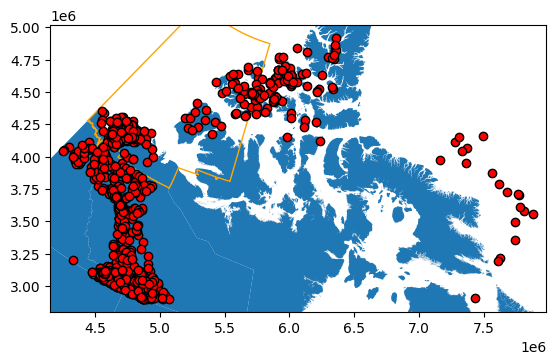

In [33]:
fig,ax=plt.subplots()
CA_boundary.plot(ax=ax)
ISR = gpd.read_file('source_data/boundary/ISR_bounds.shp').to_crs(CA_boundary.crs)
ISR.plot(ax=ax,color='None',edgecolor='orange')
CentrePoints.to_crs(CA_boundary.crs).plot(ax=ax,color='red',edgecolor='k')
blim = CentrePoints.to_crs(CA_boundary.crs).buffer(1e5).total_bounds
ax.set_xlim(blim[0],blim[2])
ax.set_ylim(blim[1],blim[3])
